# Shallow Ice Approximation (SIA) Finite Difference Solver
## Lax-Wendroff Method vs. Euler vs. Exact Analytical Solution

This notebook implements a Lax-Wendroff 2-D finite difference method that numerically solves the shallow ice approximation (SIA) partial differential equation (PDE), which is derived in:

Gopalan, G., Hrafnkelsson, B., Aðalgeirsdóttir, G., Jarosch, A. H., & Pálsson, F. (2018). A Bayesian hierarchical model for glacial dynamics based on the shallow ice approximation and its evaluation using analytical solutions. The Cryosphere, 12(7), 2229-2248.

The core logic of this approach is to integrate a Taylor approximation forward in time with two temporal derivatives of the thickness field, and to substitute spatial partial derivatives for the temporal derivatives, which are approximated with central differences.

The finite difference method is demonstrated on the periodic test case D of:

Bueler, E., Lingle, C. S., Kallen-Brown, J. A., Covey, D. N., & Bowman, L. N. (2005). Exact solutions and verification of numerical models for isothermal ice sheets. Journal of Glaciology, 51(173), 291-306,

with a mass balance forcing period of 20 years, substantially more frequent than the original 5000 year period. This is a setting where using the second time derivative of thickness provides an advantage over a method only using a first time derivative, due to a fast changing forcing.  

High frequency, oscillatory noise can be a problem with central spatial derivatives as used for the Lax-Wendroff scheme. For instance, see: Leveque, R. J. (1992). Numerical methods for conservation laws (Vol. 132). Basel: Birkhäuser. To help with this issue, it is suggested to apply a low-pass filter, as for instance in Yee, H. C., & Sjögreen, B. (2024). Numerical dissipation control in high-order methods for compressible turbulence: Recent development. Fluids, 9(6), 127. As such, we include a high-order dissipative filter based on Kreiss, H. O., & Oliger, J. (1972). Comparison of accurate methods for the integration of hyperbolic equations. Tellus, 24(3), 199-215.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

### 1. Main Finite Difference Stepping, Spatial Filter, & Finite Difference Functions

The partial differential equation being solved in the following Lax-Wendroff code is the SIA PDE (see, for instance, the Cryosphere reference above). The boundary condition is that thickness is non-negative. 



In [3]:
def lw_step(H_cur, b, b_deriv, first_order=False):
    H = H_cur
    n = N_GLEN
    H_x = diff_x(H)
    S_x = H_x + R_x
    H_xx = diff_x(H_x)
    S_xx = H_xx + R_xx
    H_y = diff_y(H)
    S_y = H_y + R_y
    H_yy = diff_y(H_y)
    H_xy = diff_y(H_x)
    S_yy = H_yy + R_yy
    S_xy = H_xy + R_xy
    S_yx = S_xy

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        alpha = (S_x**2 + S_y**2) ** ((n - 1) / 2)
        alpha_x = ((n - 1) / 2) * (S_x**2 + S_y**2) ** ((n - 3) / 2) * (2*S_x*S_xx + 2*S_y*S_yx)
        alpha_y = ((n - 1) / 2) * (S_x**2 + S_y**2) ** ((n - 3) / 2) * (2*S_y*S_yy + 2*S_x*S_xy)

        T_1 = 2*H*H_x*(H_x + R_x) + H**2*(H_xx + R_xx)
        T_2 = alpha_x*(H**(n+2)*H_x + H**(n+2)*R_x) + alpha*((n+2)*H**(n+1)*H_x**2 + (n+2)*H**(n+1)*H_x*R_x + H**(n+2)*H_xx + H**(n+2)*R_xx)
        neg_UH_x = C_0_GAMMA*RHO*G_CONST*T_1 + C_STAR*T_2

        T_3 = 2*H*H_y*(H_y + R_y) + H**2*(H_yy + R_yy)
        T_4 = alpha_y*(H**(n+2)*H_y + H**(n+2)*R_y) + alpha*((n+2)*H**(n+1)*H_y**2 + (n+2)*H**(n+1)*H_y*R_y + H**(n+2)*H_yy + H**(n+2)*R_yy)
        neg_VH_y = C_0_GAMMA*RHO*G_CONST*T_3 + C_STAR*T_4

        H_t = neg_UH_x + neg_VH_y + b

        # First-order Taylor option (Euler): H^{n+1} = H^n + H_t * dt.
        if first_order:
            H_new = H_cur + H_t * DEL_T
            H_new = np.where(np.isfinite(H_new), H_new, 0.0)
            H_new[H_new < 0] = 0.0
            return H_new, H_t, H

        H_tx = diff_x(H_t)
        H_ty = diff_y(H_t)
        H_txx = diff_x(H_tx)
        H_tyy = diff_y(H_ty)

        alpha_t = ((n - 1) / 2) * (S_x**2 + S_y**2) ** ((n - 3) / 2) * (2*S_x*H_tx + 2*S_y*H_ty)
        alpha_tx = diff_x(alpha_t)
        alpha_ty = diff_y(alpha_t)

        T_1tx = 2*H_t*H_x**2 + 4*H*H_x*H_tx + 2*H*H_tx*R_x + 2*H_t*H_x*R_x + 2*H*H_t*H_xx + H**2*H_txx + 2*H*H_t*R_xx
        T_2tx = (
            alpha_tx*H**(n+2)*H_x + alpha_x*(n+2)*H**(n+1)*H_t*H_x + alpha_x*H**(n+2)*H_tx 
            + alpha_tx*H**(n+2)*R_x + alpha_x*(n+2)*H**(n+1)*H_t*R_x 
            + alpha_t*(n+2)*H**(n+1)*H_x**2 + alpha*(n+2)*(n+1)*H**n*H_t*H_x**2 
            + alpha*(n+2)*H**(n+1)*2*H_x*H_tx 
            + alpha_t*(n+2)*H**(n+1)*H_x*R_x + alpha*(n+2)*(n+1)*H**n*H_t*H_x*R_x + alpha*(n+2)*H**(n+1)*H_tx*R_x 
            + alpha_t*H**(n+2)*H_xx 
            + alpha*(n+2)*H**(n+1)*H_t*H_xx 
            + alpha*H**(n+2)*H_txx 
            + alpha_t*H**(n+2)*R_xx 
            + alpha*(n+2)*H**(n+1)*H_t*R_xx
        )
        T_1ty = 2*H_t*H_y**2 + 4*H*H_y*H_ty + 2*H*H_ty*R_y + 2*H_t*H_y*R_y + 2*H*H_t*H_yy + H**2*H_tyy + 2*H*H_t*R_yy
        T_2ty = (
            alpha_ty*H**(n+2)*H_y + alpha_y*(n+2)*H**(n+1)*H_t*H_y + alpha_y*H**(n+2)*H_ty
            + alpha_ty*H**(n+2)*R_y + alpha_y*(n+2)*H**(n+1)*H_t*R_y
            + alpha_t*(n+2)*H**(n+1)*H_y**2 + alpha*(n+2)*(n+1)*H**n*H_t*H_y**2
            + alpha*(n+2)*H**(n+1)*2*H_y*H_ty
            + alpha_t*(n+2)*H**(n+1)*H_y*R_y + alpha*(n+2)*(n+1)*H**n*H_t*H_y*R_y + alpha*(n+2)*H**(n+1)*H_ty*R_y
            + alpha_t*H**(n+2)*H_yy
            + alpha*(n+2)*H**(n+1)*H_t*H_yy
            + alpha*H**(n+2)*H_tyy
            + alpha_t*H**(n+2)*R_yy
            + alpha*(n+2)*H**(n+1)*H_t*R_yy
        )

        neg_UH_xt = C_0_GAMMA*RHO*G_CONST*T_1tx + C_STAR*T_2tx
        neg_VH_yt = C_0_GAMMA*RHO*G_CONST*T_1ty + C_STAR*T_2ty
        H_tt = neg_UH_xt + neg_VH_yt + b_deriv
        H_new = H_cur + H_t*DEL_T + 0.5*H_tt*DEL_T**2

    H_new = np.where(np.isfinite(H_new), H_new, 0.0)
    H_new[H_new < 0] = 0.0
    return H_new, H_t, H

def diff_x(F):
    out = np.zeros_like(F, dtype=float)
    out[:, 0] = (F[:, 1] - F[:, 0]) / DEL_X
    out[:, -1] = (F[:, -1] - F[:, -2]) / DEL_X
    out[:, 1:-1] = (F[:, 2:] - F[:, :-2]) / (2.0 * DEL_X)
    return out

def diff_y(F):
    out = np.zeros_like(F, dtype=float)
    out[0, :] = (F[0, :] - F[1, :]) / DEL_Y
    out[-1, :] = (F[-2, :] - F[-1, :]) / DEL_Y
    out[1:-1, :] = (F[:-2, :] - F[2:, :]) / (2.0 * DEL_Y)
    return out

def bar_H(F):
    out = np.zeros_like(F, dtype=float)
    out[1:-1, 1:-1] = (
        F[:-2, 1:-1] + F[2:, 1:-1] + F[1:-1, :-2]
        + F[1:-1, 2:] + F[1:-1, 1:-1]
    ) / 5.0
    return out

def ko_filter(H, eps=0.04):
    #Apply high spatial-frequency damping to the finite-difference thickness field at each iteration.
    #Based off of Kreiss and Oliger (1972)
    F = H.copy()
    c = H[2:-2, 2:-2]
    d4x = H[2:-2, :-4] - 4.0 * H[2:-2, 1:-3]+ 6.0 * c - 4.0 * H[2:-2, 3:-1]+ H[2:-2, 4:]

    d4y = H[:-4, 2:-2] - 4.0 * H[1:-3, 2:-2] + 6.0 * c - 4.0 * H[3:-1, 2:-2] + H[4:, 2:-2]

    # Selectively damp short-wavelength / grid-scale content.
    F[2:-2, 2:-2] = c - (eps / 16.0) * (d4x + d4y)

    F = np.where(np.isfinite(F), F, 0.0)
    #enforce boundary condition
    F[F < 0.0] = 0.0

    return F

### 2. Bueler et al. (2005) Test Case D Functions

Same constants except make period only 20 years for mass balance oscillations -- faster changing forcing scenario. Initial condition is a dome.

In [4]:
# Constants for demo test case

#spatial resolution
DEL_X = 20_000.0
DEL_Y = 20_000.0
#temporal resolution
DEL_T = 0.25
RANGE = 1.0e6
RHO = 910.0
G = 9.80665
G_CONST = 9.80665
N_GLEN = 3
B_GLEN = 1.0e-16 / 31556926.0
C_1 = 31556926.0 * (2.0 * B_GLEN) * ((RHO * G) ** N_GLEN) / (N_GLEN + 2)
H_0 = 3600.0
R_0 = 750.0e3
F = 0.0
C_0_GAMMA = 0.0

# Test case D from Bueler et al., except use a fast 20 year mass balance period
D_L = 750.0e3
D_TP = 20.0
D_CP = 200.0
D_T0 = 5000.0

#SNAP_YEARS = list(range(1, 21))

SNAP_YEARS = [44,46,48,50,52,54,56,58,60]

def full_grid():
    m_q = int(round(RANGE / DEL_X)) + 1
    x = np.arange(-RANGE, RANGE + 0.5 * DEL_X, DEL_X)
    y = np.arange(RANGE, -RANGE - 0.5 * DEL_Y, -DEL_Y)
    X, Y = np.meshgrid(x, y)
    D = np.sqrt(X * X + Y * Y)
    return X, Y, D

X_FULL, Y_FULL, D_FULL = full_grid()
SHAPE = D_FULL.shape

R_FIELD = np.zeros(SHAPE, dtype=float)
R_x = diff_x(R_FIELD)
R_xx = diff_x(R_x)
R_y = diff_y(R_FIELD)
R_yy = diff_y(R_y)
R_xy = diff_y(R_x)
C_STAR = 31556926.0 * (2.0 * B_GLEN) * ((RHO * G_CONST) ** N_GLEN) / (N_GLEN + 2)

def D_X(r):
    return 4*r/(3*D_L) - 1/3 + (1-r/D_L)**(4/3) - (r/D_L)**(4/3)

def D_X_deriv(r):
    return -4*((r/D_L)**(1/3) + (1-r/D_L)**(1/3) - 1)/(3*D_L)

def D_X_d_deriv(r):
    with np.errstate(divide='ignore', invalid='ignore'):
        return -4*((r/D_L)**(-2/3) - (1-r/D_L)**(-2/3))/(9*D_L**2)

def D_g(r):
    return np.cos(np.pi*(r-.6*D_L)/(.6*D_L))**2

def D_g_deriv(r):
    return -np.pi*np.sin(np.pi*(r-.6*D_L)/(.3*D_L))/(.6*D_L)

def D_g_d_deriv(r):
    return -np.pi**2*np.cos(np.pi*(r-.6*D_L)/(.3*D_L))/(.18*D_L**2)

def D_H_s(r):
    s = r/D_L
    s_clip = np.clip(s, 0.0, 1.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        q = (1+1/N_GLEN)*s_clip - 1/N_GLEN + (1-s_clip)**(1+1/N_GLEN) - s_clip**(1+1/N_GLEN)
        out = H_0/(1-1/N_GLEN)**(N_GLEN/(2*N_GLEN+2)) * q**(N_GLEN/(2*N_GLEN+2))
    return np.where((s >= 0) & (s <= 1) & (q > 0), out, 0.0)

def D_P(r,t):
    out = np.zeros_like(r)
    mask = (r < .9*D_L) & (r > .3*D_L)
    out[mask] = D_CP*np.sin(2*np.pi*t/D_TP)*np.cos(np.pi*(r[mask]-.6*D_L)/(.6*D_L))**2
    return out

def D_H_true(r,t):
    return D_H_s(r) + D_P(r,t)

def D_H_s_deriv(r):
    x = D_X(r)
    with np.errstate(divide='ignore', invalid='ignore'):
        out = 3*H_0*x**(-5/8)*D_X_deriv(r)/(8*(2/3)**(3/8))
    return np.where(np.isfinite(out), out, 0.0)

def D_H_ss(r):
    x = D_X(r)
    with np.errstate(divide='ignore', invalid='ignore'):
        out = 3*H_0*(-5*x**(-13/8)/8*D_X_deriv(r)**2 + x**(-5/8)*D_X_d_deriv(r))/(8*(2/3)**(3/8))
    return np.where(np.isfinite(out), out, 0.0)

def D_H_p_deriv(r,t):
    return D_H_s_deriv(r) + D_CP*np.sin(2*np.pi*t/D_TP)*D_g_deriv(r)

def D_H_p_d_deriv(r,t):
    return D_H_ss(r) + D_CP*np.sin(2*np.pi*t/D_TP)*D_g_d_deriv(r)

def D_M_s(r):
    C = (1-F)**N_GLEN*C_1*H_0**(2*N_GLEN+2)/(2*(1-1/N_GLEN)*D_L)**N_GLEN
    s = r/D_L
    with np.errstate(divide='ignore', invalid='ignore'):
        out = C*(s**(1/N_GLEN)+(1-s)**(1/N_GLEN)-1)**(N_GLEN-1)*(2*s**(1/N_GLEN)+(1-s)**(1/N_GLEN-1)*(1-2*s)-1)/(D_L*s)
    return np.where(np.isfinite(out), out, 0.0)

def D_M_c(r,t):
    out = np.zeros_like(r)
    mask = (r < .9*D_L) & (r > .3*D_L)
    rr = r[mask]
    Hp = D_H_true(rr,t)
    Hpd = D_H_p_deriv(rr,t)
    T1 = 2*np.pi*D_CP*D_g(rr)*np.cos(2*np.pi*t/D_TP)/D_TP
    T2 = -D_M_s(rr)
    T3 = -C_1*Hp**4*Hpd**2*(Hp*Hpd/rr + 5*Hpd**2 + 3*Hp*D_H_p_d_deriv(rr,t))
    out[mask] = T1 + T2 + T3
    return np.where(np.isfinite(out), out, 0.0)

def D_MB(r,t):
    return D_M_s(r) + D_M_c(r,t)

### 3. Numerical Integration (Euler vs. Lax-Wendroff solvers)

Run to generate comparison solutions with Euler with Lax-Wendroff. Comment out ko_filter to see the effect of including the lowpass spatial filter at each iteration (longer-term stability).

In [5]:
H_initial = D_H_true(D_FULL, D_T0)
snapshot_steps = {int(round(year / DEL_T)): year for year in SNAP_YEARS}

Euler_runs = {}
H = H_initial.copy()
for k in range(1, int(round(max(SNAP_YEARS) / DEL_T)) + 1):
    t = D_T0 + (k - 1) * DEL_T
    b = D_MB(D_FULL, t)
    H, _, _ = lw_step(H, b, b, first_order=True)
    #comment out to see effect of filter
    H = ko_filter(H, eps=.04)
    if k in snapshot_steps:
        Euler_runs[snapshot_steps[k]] = H.copy()

LW_runs = {}
H = H_initial.copy()
b_old = D_MB(D_FULL, D_T0)
b = b_old.copy()
for k in range(1, int(round(max(SNAP_YEARS) / DEL_T)) + 1):
    cur_t = D_T0 + k * DEL_T
    b_deriv = (b - b_old) / DEL_T
    H, _, _ = lw_step(H, b, b_deriv, first_order=False)
    #comment out to see effect of filter
    H = ko_filter(H, eps=.04)
    b_old = b.copy()
    b = D_MB(D_FULL, cur_t)
    if k in snapshot_steps:
        LW_runs[snapshot_steps[k]] = H.copy()

### 4. Interior Error Metrics

In [6]:
interior_mask = (D_FULL > 0.3 * D_L) & (D_FULL < 0.9 * D_L)

rows = []
for year in SNAP_YEARS:
    H_true = D_H_true(D_FULL, D_T0 + year)
    for method_name, H_num in [
        ("Euler", Euler_runs[year]),
        ("Lax-Wendroff", LW_runs[year])
    ]:
        e = H_num[interior_mask] - H_true[interior_mask]
        rows.append([
            year, method_name,
            float(np.sqrt(np.mean(e**2))),
            float(np.mean(np.abs(e)))
        ])

rmse_table = pd.DataFrame(
    rows,
    columns=["Years", "Method", "Interior_RMSE_m", "Interior_MAE_m"]
)
print(rmse_table.to_string(index=False))

 Years       Method  Interior_RMSE_m  Interior_MAE_m
    44        Euler         2.366762        2.232871
    44 Lax-Wendroff         0.505419        0.390351
    46        Euler         5.219519        4.637609
    46 Lax-Wendroff         0.612648        0.459975
    48        Euler         7.555653        6.594108
    48 Lax-Wendroff         0.653091        0.443670
    50        Euler         8.413674        7.342241
    50 Lax-Wendroff         0.667900        0.393261
    52        Euler         7.455291        6.604022
    52 Lax-Wendroff         0.722479        0.529773
    54        Euler         5.066280        4.645377
    54 Lax-Wendroff         0.809123        0.662761
    56        Euler         2.320303        2.203000
    56 Lax-Wendroff         0.863973        0.716259
    58        Euler         1.433476        1.230061
    58 Lax-Wendroff         0.847448        0.671020
    60        Euler         1.908679        1.572321
    60 Lax-Wendroff         0.800351        0.

### 5. Radial Change-from-$t_0$ Plot

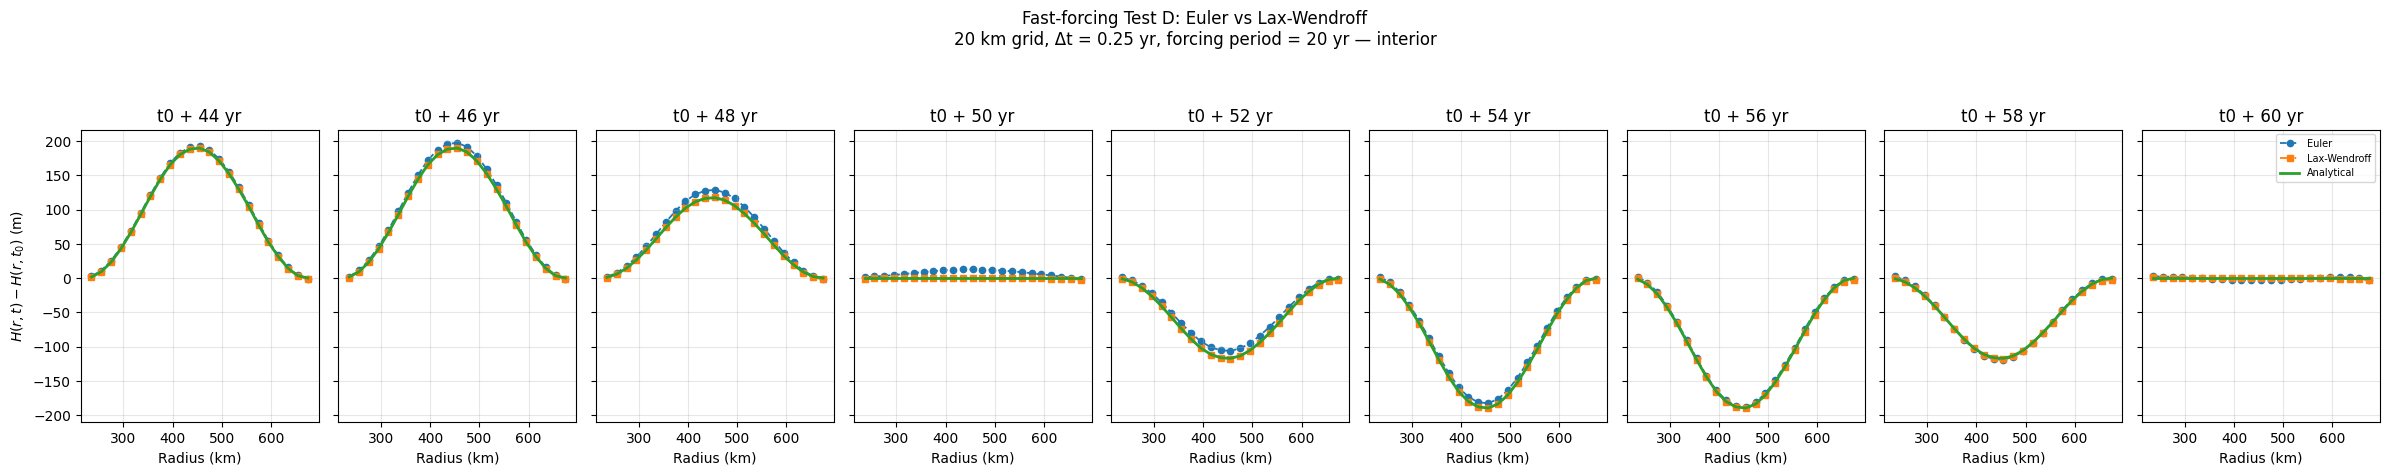

In [7]:
r_km = D_FULL / 1000.0
bin_edges = np.arange(0.3 * D_L / 1000.0, 0.9 * D_L / 1000.0 + 20.0, 20.0)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def radial_average(field):
    values = []
    for r1, r2 in zip(bin_edges[:-1], bin_edges[1:]):
        m = (r_km >= r1) & (r_km < r2)
        values.append(float(np.mean(field[m])) if np.any(m) else np.nan)
    return np.asarray(values)

profile_rows = []
for year in SNAP_YEARS:
    H_true = D_H_true(D_FULL, D_T0 + year)

    for rr, vv in zip(bin_centers, radial_average(H_true - H_initial)):
        profile_rows.append(["Analytical", year, rr, vv])

    for method_name, H_num in [
        ("Euler", Euler_runs[year]),
        ("Lax-Wendroff", LW_runs[year]),
    ]:
        for rr, vv in zip(bin_centers, radial_average(H_num - H_initial)):
            profile_rows.append([method_name, year, rr, vv])

profiles = pd.DataFrame(
    profile_rows,
    columns=["Series", "Years", "radius_km", "delta_H_m"]
)

vals = profiles["delta_H_m"].dropna()
pad = 0.05 * (vals.max() - vals.min())
ylim = (vals.min() - pad, vals.max() + pad)

fig, axes = plt.subplots(1, len(SNAP_YEARS), figsize=(24, 4.8), sharey=True)

# Set analytical to draw over numerical methods with high zorder, distinct color, and clear marker
series_config = [
    ("Euler", "--", "o", 1.3, "tab:blue", 1),
    ("Lax-Wendroff", "-.", "s", 1.3, "tab:orange", 2),
    ("Analytical", "-", None, 2.0, "tab:green", 10)
]

for ax, year in zip(axes, SNAP_YEARS):
    for series, ls, mk, lw, color, zo in series_config:
        g = profiles[(profiles["Series"] == series) & (profiles["Years"] == year)].sort_values("radius_km")
        ax.plot(
            g["radius_km"], g["delta_H_m"],
            linestyle=ls, marker=mk, markersize=4.5,
            linewidth=lw, color=color, label=series, zorder=zo
        )
    ax.set_title(f"t0 + {year} yr")
    ax.set_xlabel("Radius (km)")
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$H(r,t)-H(r,t_0)$ (m)")
axes[-1].legend(fontsize=7, loc="best")
fig.suptitle(
    "Fast-forcing Test D: Euler vs Lax-Wendroff\n"
    "20 km grid, Δt = 0.25 yr, forcing period = 20 yr — interior"
)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()